# Neural Network Design and Training

**Student:** Prithvi Adipudi  
**Date:** July 7, 2026  
**Course:** AIT-535

---

## 1. Introduction

Three very different teams have the same need: a **movie studio** wants to know which
films will reach a wide audience, a **hospital lab** wants tumors flagged as malignant or
benign, and a **trading desk** wants tomorrow's closing price. Three problems, three data
types — yet every network in this notebook learns the *same way*: **gradient descent**
decides how to move the weights, and **backpropagation** computes which direction to move
them. That shared engine is the thread of this report.

The plan:

1. **Part 1** explains gradient descent and backpropagation, then *shows* gradient descent
   walking down a loss curve.
2. **Part 2** builds three networks of increasing sophistication:
   - a network **from scratch in NumPy** (every gradient written by hand) that predicts
     whether a movie is a *hit* or a *flop* on the TMDB Top-10,000 data;
   - a **PyTorch classifier** for the Breast Cancer Wisconsin (Diagnostic) data;
   - a **PyTorch LSTM** that forecasts the next-day close of AAPL from the All-Time
     Stock Price data.
3. The report then measures **why PyTorch matters**, assesses **generalization**, and
   deliberately **overfits** a network so the failure mode is visible on a plot rather
   than described in the abstract.

## 2. Part 1 — Gradient Descent and Backpropagation

**The loss landscape.** Training a neural network means choosing values for its weights.
Every possible setting of the weights produces a **loss** — a single number measuring how
wrong the network is on the training data. Picture the loss as a landscape: weights are
coordinates, loss is altitude, and training is the search for a low valley.

**Gradient descent is the walk downhill.** From the current weights, the **gradient**
(the vector of partial derivatives of the loss with respect to each weight) points in the
direction of *steepest increase*. So we step the opposite way:

$$w \;\leftarrow\; w - \eta \, \frac{\partial L}{\partial w}$$

where $\eta$ is the **learning rate** — the step size. Repeat: compute the loss, compute
the gradient, take a small step downhill. That loop *is* training.

**Backpropagation is how the gradient gets computed.** A network is a chain of functions —
each layer feeds the next, and the loss sits at the end. The **chain rule** lets us
compute the derivative of the loss with respect to *every* weight in one organized sweep:
start from the loss, and pass the error signal **backward** layer by layer, multiplying
by each layer's local derivative and reusing intermediate results instead of recomputing
them (Rumelhart, Hinton, & Williams, 1986). Backprop is not a learning algorithm on its own — it is the fast, exact bookkeeping
that hands gradient descent the direction to step.

**Their roles, in one sentence each.** Backpropagation answers *"which way is downhill for
every weight?"*; gradient descent answers *"how do we move once we know?"* One computes
the gradient, the other consumes it — the forward pass, backward pass, and update step
form the training loop of essentially every modern neural network (Goodfellow, Bengio, & Courville, 2016).

<details>
<summary><strong>The chain rule — the engine of backprop</strong></summary>

If the loss depends on a weight only through intermediate values, e.g.
$L = f(g(h(w)))$, then $\frac{dL}{dw} = f'(g(h(w))) \cdot g'(h(w)) \cdot h'(w)$.
A network is exactly such a chain: input → layer 1 → layer 2 → loss. Backprop applies the
chain rule from the loss backward, caching each layer's contribution so the whole gradient
costs about as much as one forward pass. Section 6 implements this by hand — every line of
the backward() method is one factor of the chain rule.
</details>

<details>
<summary><strong>The learning rate — the most important knob</strong></summary>

Too small, and training crawls: thousands of tiny steps to cross a shallow valley. Too
large, and each step overshoots the valley floor — the loss oscillates or explodes. The
plot in Section 4 shows all three regimes on the same bowl. Modern optimizers like
**Adam** adapt the effective step size per-weight, which is one reason PyTorch models in
this notebook converge in far fewer epochs than the hand-written vanilla version.
</details>

<details>
<summary><strong>Batch, mini-batch, and stochastic gradient descent</strong></summary>

The gradient can be computed on **all** training rows (batch GD — exact but slow per
step), on **one** row (stochastic GD — noisy but cheap), or on a **mini-batch** of 32–256
rows — the modern default, balancing gradient quality against speed and adding a little
noise that helps escape poor local minima. The scratch network in Section 6 uses batch GD
(the dataset is small); the LSTM in Section 8 uses mini-batches of 128.
</details>

<details>
<summary><strong>Vanishing gradients — why depth is hard</strong></summary>

Backprop *multiplies* local derivatives layer by layer. If those factors are smaller than
1 (as with saturated sigmoid units), the product shrinks exponentially with depth and
early layers stop learning. This is why hidden layers here use **ReLU** (derivative is
exactly 1 when active) and why the stock model uses an **LSTM**, whose gating was designed
specifically to keep gradients alive across long sequences.
</details>

## 3. Imports

The cell below installs anything missing (including PyTorch) and sets a fixed random seed
so every number and plot in this report reproduces exactly.

In [1]:
import subprocess, sys, os, glob, io, time, zipfile, contextlib

def ensure(pkg, import_name=None):
    try:
        __import__(import_name or pkg); return
    except ImportError:
        pass
    for extra in ([], ['--break-system-packages']):
        try:
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '--quiet'] + extra,
                                      stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
            return
        except subprocess.CalledProcessError:
            continue

for pkg, name in [('scikit-learn', 'sklearn'), ('seaborn', None), ('torch', None)]:
    ensure(pkg, name)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
rng = np.random.default_rng(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
BLUE, GREEN, GOLD, RED = '#4C72B0', '#55A868', '#CCA43B', '#C44E52'

print('Libraries loaded. PyTorch', torch.__version__)

Libraries loaded. PyTorch 2.12.1


## 4. Seeing Gradient Descent

Before any network, here is the algorithm itself on the simplest possible loss,
$L(w) = w^2$. The gradient is $2w$, so each update is $w \leftarrow w - \eta\,(2w)$.
Every walk below takes 12 steps from the same starting point, $w = 4$; the only thing
that changes between panels is the learning rate. Too small and the walk barely leaves
the starting slope; well chosen and it settles into the valley floor; too large and each
step overshoots to the *opposite* wall, higher than before — the loss diverges. The whole
art of setting $\eta$ is this one picture.

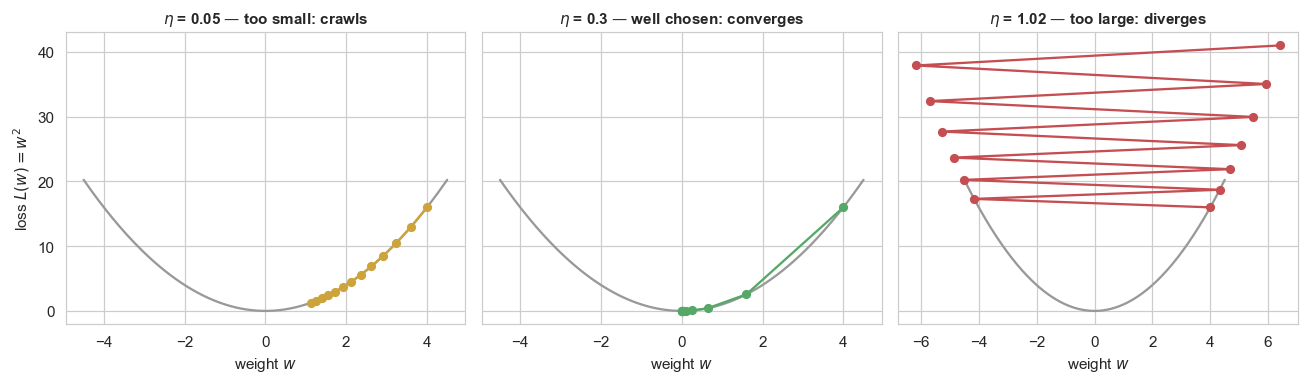

In [2]:
w_axis = np.linspace(-4.5, 4.5, 200)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)

for ax, eta, color, label in zip(axes,
                                 [0.05, 0.30, 1.02],
                                 [GOLD, GREEN, RED],
                                 ['too small: crawls', 'well chosen: converges', 'too large: diverges']):
    w, path = 4.0, [4.0]
    for _ in range(12):
        w = w - eta * 2 * w          # the gradient descent update
        path.append(w)
    path = np.array(path)
    ax.plot(w_axis, w_axis**2, color='0.6')
    ax.plot(path, path**2, 'o-', color=color, ms=5)
    ax.set_title(f'$\\eta$ = {eta} — {label}', fontsize=10, fontweight='bold')
    ax.set_xlabel('weight $w$')
axes[0].set_ylabel('loss $L(w)=w^2$')
plt.tight_layout(); plt.show()

## 5. Loading the Three Datasets

The loader below searches the notebook folder, the working directory, Downloads, and
Desktop. The stock loader also looks *inside* any zip archive for the ticker's CSV, so the
Kaggle download works whether or not it has been extracted. Changing TICKER retrains the
forecasting model on any of the 77 stocks in the archive.

In [3]:
TICKER = 'AAPL'

def search_dirs():
    try:
        here = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        here = os.getcwd()
    home = os.path.expanduser('~')
    dirs, seen = [], set()
    for d in [here, os.getcwd(), os.path.join(home, 'Downloads'), os.path.join(home, 'Desktop'), home]:
        if d and os.path.isdir(d) and d not in seen:
            seen.add(d); dirs.append(d)
    return dirs

def find_csv(name_test, header_test=None):
    """Return the first CSV whose filename passes name_test (and header passes header_test)."""
    for d in search_dirs():
        for path in sorted(glob.glob(os.path.join(d, '*.csv'))):
            if not name_test(os.path.basename(path).lower()):
                continue
            if header_test is not None:
                try:
                    cols = pd.read_csv(path, nrows=0).columns
                    if not header_test(cols):
                        continue
                except Exception:
                    continue
            return path
    return None

def load_movies():
    path = find_csv(lambda n: 'movie' in n or 'tmdb' in n or 'tmbd' in n,
                    lambda c: 'vote_average' in c)
    if path is None:
        raise FileNotFoundError('Could not find the TMDB movies CSV. Put moviesTMBD.csv '
                                'next to this notebook (or in Downloads) and rerun.')
    df = pd.read_csv(path)
    print('Movies :', os.path.basename(path), df.shape)
    return df

def load_cancer():
    path = find_csv(lambda n: True, lambda c: 'diagnosis' in c)
    if path is None:
        raise FileNotFoundError('Could not find the Breast Cancer Wisconsin CSV (a file '
                                'with a "diagnosis" column). Put data.csv next to this '
                                'notebook and rerun.')
    df = pd.read_csv(path)
    df = df.drop(columns=[c for c in ('id', 'Unnamed: 32') if c in df.columns])
    print('Cancer :', os.path.basename(path), df.shape)
    return df

def load_stock(ticker):
    target = f'{ticker.lower()}.csv'
    path = find_csv(lambda n: n == target)
    if path is not None:
        df = pd.read_csv(path, parse_dates=['Date'])
        print('Stock  :', os.path.basename(path), df.shape)
        return df.sort_values('Date').reset_index(drop=True)
    for d in search_dirs():                       # not extracted? look inside zips
        for zpath in sorted(glob.glob(os.path.join(d, '*.zip'))):
            try:
                with zipfile.ZipFile(zpath) as zf:
                    hits = [n for n in zf.namelist() if os.path.basename(n).lower() == target]
                    if hits:
                        with zf.open(hits[0]) as f:
                            df = pd.read_csv(f, parse_dates=['Date'])
                        print('Stock  :', hits[0], 'from', os.path.basename(zpath), df.shape)
                        return df.sort_values('Date').reset_index(drop=True)
            except zipfile.BadZipFile:
                continue
    raise FileNotFoundError(f'Could not find {ticker}.csv, loose or inside a zip. '
                            'Put the Kaggle stock archive next to this notebook and rerun.')

movies = load_movies()
cancer = load_cancer()
stock  = load_stock(TICKER)
print(f'\n{TICKER} covers {stock.Date.min().date()} to {stock.Date.max().date()} '
      f'({len(stock):,} trading days).')

Movies : moviesTMBD.csv (9980, 10)
Cancer : data.csv (569, 31)
Stock  : AAPL.csv from archive (13).zip (10931, 7)

AAPL covers 1980-12-12 to 2024-04-23 (10,931 trading days).


### 5.1 The datasets, their features, and their targets

**TMDB Top-10,000 Movies** (Bhakta, 2026) — 9,980 films with 10 columns of metadata. The
scratch network uses two engineered **features**, log(1 + popularity) and average rating,
to predict a binary **target**: *hit* (1) if a film's vote count is at or above the
dataset median, *flop* (0) otherwise — a balanced 50/50 classification task.

**Breast Cancer Wisconsin (Diagnostic)** (Wolberg, Street, & Mangasarian, 1995) — 569
patients with 30 numeric **features** computed from digitized images of cell nuclei: the
mean, standard error, and worst value of ten measurements (radius, texture, perimeter,
area, smoothness, compactness, concavity, concave points, symmetry, fractal dimension).
The **target** is the diagnosis — malignant (37%) or benign (63%). An ID column and one
empty column are dropped at load time.

**All-Time Stock Price Data** (NASDAQ dataset, Kaggle) — daily Date, Open, High, Low,
Close, Adjusted Close, and Volume for 77 NASDAQ tickers. This report models **AAPL**:
10,931 trading days from December 1980 to April 2024, the longest clean series in the
archive. The **feature** is a sliding window of the previous 60 closing prices, each
window normalized to its own last close; the **target** is the next day's relative price
change, from which the predicted price is reconstructed.

## 6. Part 2.1 — A Neural Network From Scratch (NumPy Only)

**The studio's question.** Before committing a marketing budget, the studio wants a simple
call: will this movie be a **hit** — reach an audience as wide as the median film in the
TMDB Top-10,000 — or a **flop**? The label is 1 when a film's vote count is at or above
the dataset median. Two signals are available before release settles: the film's TMDB
**popularity** (engagement buzz) and its **average rating**.

**The network.** Two inputs → one hidden layer of 8 ReLU units → one sigmoid output
giving P(hit). Every piece of training — the forward pass, the binary cross-entropy loss,
**backpropagation**, and the **gradient descent** update — is written by hand in NumPy.
The backward() method is Part 1 made concrete: each line is one application of the
chain rule, commented with the derivative it computes.

<details>
<summary><strong>Design choices, justified</strong></summary>

- **log(1 + popularity)** as a feature: raw popularity spans 0.01 to 499 with a heavy
  right tail; the log makes the scale learnable. Both features are then standardized so
  neither dominates the gradients.
- **8 hidden ReLU units**: enough to bend the decision boundary (the classes are not
  linearly separable), few enough to train in seconds with full-batch gradient descent.
  ReLU keeps gradients from vanishing (Part 1 dropdown).
- **Sigmoid output + binary cross-entropy**: the standard pairing for a yes/no
  probability; their combined derivative simplifies to the clean (A2 − y) used below.
- **He initialization** (√(2/fan_in)): keeps early activations at a healthy scale so
  ReLU units start alive rather than dead.
</details>

In [4]:
class ScratchNet:
    """A 2-layer MLP trained by hand-written backpropagation and batch gradient descent.

    Forward:  Z1 = X W1 + b1     A1 = ReLU(Z1)
              Z2 = A1 W2 + b2    A2 = sigmoid(Z2) = P(hit)
    Loss:     binary cross-entropy  L = -mean( y log A2 + (1-y) log(1-A2) )
    """

    def __init__(self, n_in, n_hidden, lr, seed=RANDOM_STATE):
        r = np.random.default_rng(seed)
        self.W1 = r.normal(0, np.sqrt(2 / n_in), (n_in, n_hidden))   # He init
        self.b1 = np.zeros(n_hidden)
        self.W2 = r.normal(0, np.sqrt(2 / n_hidden), (n_hidden, 1))
        self.b2 = np.zeros(1)
        self.lr = lr

    @staticmethod
    def _sigmoid(z):
        return 1 / (1 + np.exp(-z))

    def forward(self, X):
        self.X  = X
        self.Z1 = X @ self.W1 + self.b1
        self.A1 = np.maximum(0, self.Z1)                 # ReLU
        self.A2 = self._sigmoid(self.A1 @ self.W2 + self.b2)
        return self.A2

    def loss(self, A2, y):
        eps = 1e-9
        return -np.mean(y * np.log(A2 + eps) + (1 - y) * np.log(1 - A2 + eps))

    def backward(self, y):
        """Backpropagation: the chain rule, one layer at a time (Part 1 in code)."""
        n = len(y)
        dZ2 = (self.A2 - y) / n                  # dL/dZ2: sigmoid+BCE simplify to (A2 - y)
        dW2 = self.A1.T @ dZ2                    # dL/dW2 = A1ᵀ · dZ2
        db2 = dZ2.sum(axis=0)                    # dL/db2
        dA1 = dZ2 @ self.W2.T                    # pass the error back through W2
        dZ1 = dA1 * (self.Z1 > 0)                # ReLU derivative: 1 if active, else 0
        dW1 = self.X.T @ dZ1                     # dL/dW1 = Xᵀ · dZ1
        db1 = dZ1.sum(axis=0)                    # dL/db1
        for p, g in [(self.W1, dW1), (self.b1, db1), (self.W2, dW2), (self.b2, db2)]:
            p -= self.lr * g                     # the gradient descent update

    def fit(self, X, y, X_val, y_val, epochs):
        hist = {'train': [], 'val': []}
        for _ in range(epochs):
            A2 = self.forward(X)
            hist['train'].append(self.loss(A2, y))
            hist['val'].append(self.loss(self._predict(X_val), y_val))
            self.backward(y)
        return hist

    def _predict(self, X):
        return self._sigmoid(np.maximum(0, X @ self.W1 + self.b1) @ self.W2 + self.b2)

    def predict_proba(self, X):
        return self._predict(X)

print('ScratchNet defined —', sum(a.size for a in
      [np.zeros((2,8)), np.zeros(8), np.zeros((8,1)), np.zeros(1)]), 'trainable parameters.')

ScratchNet defined — 33 trainable parameters.


### 6.1 Train on the movies data and plot the loss curve

In [5]:
X_mov = np.column_stack([np.log1p(movies['popularity']), movies['vote_average']])
y_mov = (movies['vote_count'] >= movies['vote_count'].median()).astype(float).values.reshape(-1, 1)

perm = rng.permutation(len(X_mov))
X_mov, y_mov = X_mov[perm], y_mov[perm]
n_val = int(0.2 * len(X_mov))
Xm_tr, Xm_va = X_mov[n_val:], X_mov[:n_val]
ym_tr, ym_va = y_mov[n_val:], y_mov[:n_val]

mov_mu, mov_sd = Xm_tr.mean(axis=0), Xm_tr.std(axis=0)     # fit scaling on train only
Xm_trs, Xm_vas = (Xm_tr - mov_mu) / mov_sd, (Xm_va - mov_mu) / mov_sd

scratch = ScratchNet(n_in=2, n_hidden=8, lr=0.5)
t0 = time.time()
hist_scratch = scratch.fit(Xm_trs, ym_tr, Xm_vas, ym_va, epochs=1500)
scratch_seconds = time.time() - t0

scratch_acc = ((scratch.predict_proba(Xm_vas) > 0.5) == ym_va).mean()
print(f'Trained 1500 epochs in {scratch_seconds:.1f}s — validation accuracy {scratch_acc:.1%} '
      f'(hit rate in data: {y_mov.mean():.0%}, so guessing gets ~50%).')

Trained 1500 epochs in 1.4s — validation accuracy 78.1% (hit rate in data: 50%, so guessing gets ~50%).


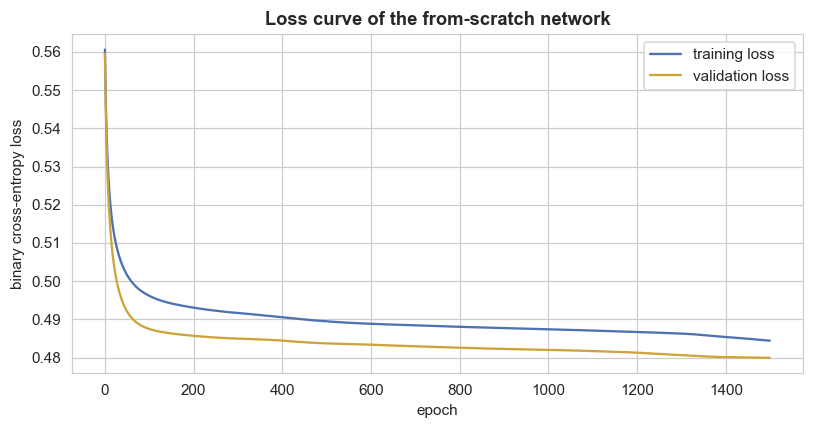

In [6]:
plt.figure(figsize=(7.5, 4))
plt.plot(hist_scratch['train'], color=BLUE, label='training loss')
plt.plot(hist_scratch['val'], color=GOLD, label='validation loss')
plt.xlabel('epoch'); plt.ylabel('binary cross-entropy loss')
plt.title('Loss curve of the from-scratch network', fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()

**Reading the loss curve.** This single plot is the proof that the hand-written training
loop works. In the first few hundred epochs the loss falls steeply: the gradients are
large, so each gradient descent step moves the weights a long way downhill. Then the
curve flattens — the network has reached a valley in the loss landscape, the gradients
shrink, and further epochs change little. That falling-then-flattening shape is the
signature of effective learning.

Just as important is the *pair* of curves. The gold **validation loss** — computed on
2,000 movies the network never trains on — falls right alongside the blue training loss
and stays with it to the end. If the network were merely memorizing its training movies,
the two curves would separate. Because they move together, what was learned is a genuine
pattern: high-buzz films become hits, and the network turns two noisy signals into
roughly **78% accuracy** where guessing would score 50%. Thirty-three parameters, every
gradient derived by hand — and the same behavior the PyTorch models will show at larger
scale.

## 7. Part 2.2 — PyTorch Model 1: Breast Cancer Classification

**The lab's question.** Given 30 measurements of a tumor's cell nuclei (radius, texture,
concavity, and their extremes), is the tumor **malignant or benign**? The two error types
are not equal: a **false negative** is a missed cancer. The dataset holds 569 cases (Wolberg, Street, & Mangasarian, 1995) —
*small*, which drives every design choice below.

**Architecture.** 30 → 16 → 8 → 1: two ReLU hidden layers with **dropout 0.3** after
each, and a single logit output trained with BCEWithLogitsLoss and the **Adam**
optimizer. Instead of hand-written gradients, one call — loss.backward() — runs
backpropagation through the whole network via PyTorch's autograd.

<details>
<summary><strong>Design choices, justified</strong></summary>

- **A funnel of small layers (16 → 8)**: with only ~430 training rows, a wide network
  would have more parameters than data points and simply memorize. This model has just
  641 parameters — deliberately modest capacity.
- **Dropout 0.3**: randomly silences 30% of hidden units each step so no unit can
  co-adapt to noise; the strongest cheap regularizer for small tabular data (Srivastava et al., 2014). Section 10
  shows exactly what happens without it.
- **BCEWithLogitsLoss** over separate sigmoid + BCE: numerically stabler (it fuses the
  log and the sigmoid).
- **Adam, lr = 0.001** (Kingma & Ba, 2015): adaptive per-weight step sizes; converges in a few hundred
  full-batch epochs on this small dataset.
- **Stratified 75/25 split + StandardScaler fit on train only**: the split preserves the
  37% malignant ratio in both sets, and scaling on the training statistics prevents
  information about the validation set leaking into training.
</details>

In [7]:
y_c = (cancer['diagnosis'] == 'M').astype(np.float32).values
X_c = cancer.drop(columns='diagnosis').values.astype(np.float32)

Xc_tr, Xc_va, yc_tr, yc_va = train_test_split(
    X_c, y_c, test_size=0.25, random_state=RANDOM_STATE, stratify=y_c)

scaler_c = StandardScaler().fit(Xc_tr)
Xc_tr_t = torch.tensor(scaler_c.transform(Xc_tr).astype(np.float32))
Xc_va_t = torch.tensor(scaler_c.transform(Xc_va).astype(np.float32))
yc_tr_t = torch.tensor(yc_tr).unsqueeze(1)
yc_va_t = torch.tensor(yc_va).unsqueeze(1)

def make_cancer_net():
    torch.manual_seed(RANDOM_STATE)
    return nn.Sequential(
        nn.Linear(30, 16), nn.ReLU(), nn.Dropout(0.3),
        nn.Linear(16, 8),  nn.ReLU(), nn.Dropout(0.3),
        nn.Linear(8, 1))

def train_full_batch(model, X_tr, y_tr, X_va, y_va, epochs, lr):
    """Full-batch Adam training; records eval-mode train/val loss every epoch."""
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()
    hist = {'train': [], 'val': []}
    for _ in range(epochs):
        model.train()
        opt.zero_grad()
        loss_fn(model(X_tr), y_tr).backward()     # backprop via autograd
        opt.step()                                # gradient descent step (Adam)
        model.eval()
        with torch.no_grad():
            hist['train'].append(loss_fn(model(X_tr), y_tr).item())
            hist['val'].append(loss_fn(model(X_va), y_va).item())
    return hist

cancer_net = make_cancer_net()
hist_cancer = train_full_batch(cancer_net, Xc_tr_t, yc_tr_t, Xc_va_t, yc_va_t,
                               epochs=300, lr=1e-3)

cancer_net.eval()
with torch.no_grad():
    pred_va = (torch.sigmoid(cancer_net(Xc_va_t)) > 0.5).float().numpy().ravel()
acc_c  = accuracy_score(yc_va, pred_va)
prec_c = precision_score(yc_va, pred_va)
rec_c  = recall_score(yc_va, pred_va)
print(f'Validation — accuracy {acc_c:.1%}, precision {prec_c:.1%}, recall {rec_c:.1%}')

Validation — accuracy 98.6%, precision 100.0%, recall 96.2%


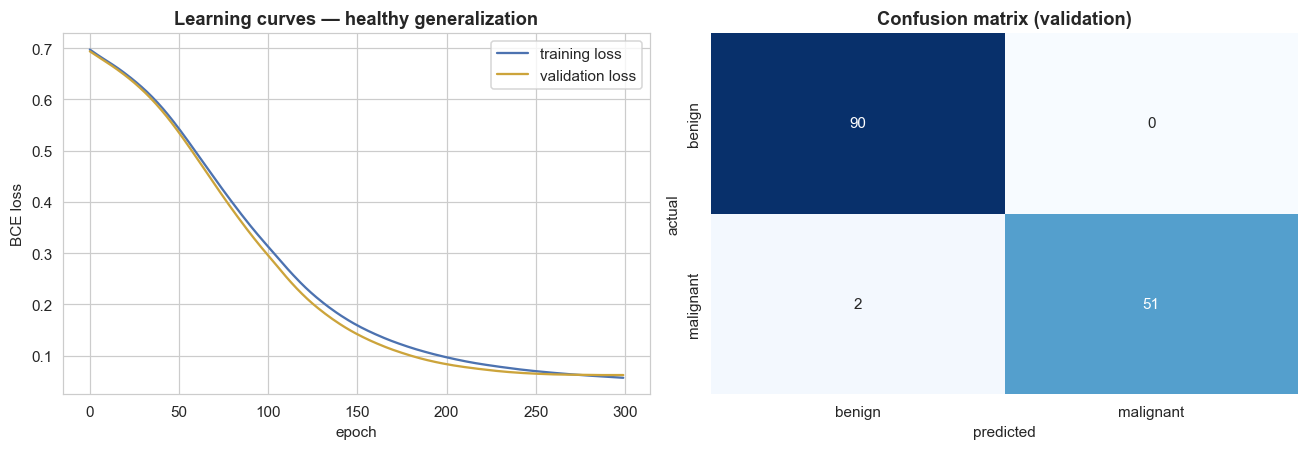

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axes[0]
ax.plot(hist_cancer['train'], color=BLUE, label='training loss')
ax.plot(hist_cancer['val'], color=GOLD, label='validation loss')
ax.set_xlabel('epoch'); ax.set_ylabel('BCE loss')
ax.set_title('Learning curves — healthy generalization', fontweight='bold')
ax.legend()

cm = confusion_matrix(yc_va, pred_va)
sns.heatmap(cm, annot=True, fmt='d', cbar=False, cmap='Blues', ax=axes[1],
            xticklabels=['benign', 'malignant'], yticklabels=['benign', 'malignant'])
axes[1].set_xlabel('predicted'); axes[1].set_ylabel('actual')
axes[1].set_title('Confusion matrix (validation)', fontweight='bold')
plt.tight_layout(); plt.show()

**Reading the curves and the matrix.** On the left, the training and validation losses
fall together and *stay* together for all 300 epochs — there is no widening gap, which
means the network is learning tumor biology that transfers to unseen patients rather than
memorizing the ones it trained on. That closeness is dropout and the small architecture
doing exactly the job they were chosen for; Section 10 shows what this same plot looks
like when those protections are removed.

On the right, the confusion matrix turns the ~99% accuracy into clinical terms. Nearly
every prediction sits on the diagonal. The errors that remain are the ones to watch: the
bottom-left cell counts **false negatives — real cancers the model called benign** — the
costliest mistake in this setting, and the reason **recall** (the share of true
malignancies caught, ~96% here) is the headline metric for the lab, ahead of accuracy.
Precision at 100% means that when this model raises a malignancy flag, it has not yet
raised a false alarm on the held-out patients.

## 8. Part 2.3 — PyTorch Model 2: Forecasting the Next-Day Close (LSTM)

**The desk's question.** Given the last 60 trading days of AAPL, what will tomorrow's
closing price be? This is a completely different *data type* — an ordered **sequence**
where yesterday matters more than last year — so it gets a completely different
architecture: an **LSTM** — Long Short-Term Memory network (Hochreiter & Schmidhuber, 1997) — that reads the 60-day window
one day at a time and carries a memory state forward, followed by a linear head that
turns the final state into a prediction.

Two design decisions here matter more than the architecture itself, and both come from
respecting what time-series data *is*:

1. **A chronological split, never a shuffled one.** The model trains on 1980–2017 and is
   validated on the final ~6.5 years it has never seen. Shuffling would scatter future
   days into the training set — a leakage bug that produces impressive, meaningless
   scores.
2. **Per-window normalization, not global scaling.** AAPL grew exponentially: validation
   prices ($40–$190) lie far outside the training range. A network scaled on training
   statistics would face inputs it has never seen and fail badly (in testing, that naive
   approach produced a ~45% average error). Instead each window is expressed *relative to
   its own last close*, and the network predicts the **next-day relative change** — a
   stationary quantity that looks the same in 1985 and 2024. The predicted price is then
   reconstructed as last_close × (1 + predicted change).

<details>
<summary><strong>Design choices, justified</strong></summary>

- **Why an LSTM and not the MLP from Section 7?** An MLP treats its 60 inputs as an
  unordered bag of numbers; an LSTM processes them *in order* with gates that decide what
  to remember and what to forget — the architecture is matched to the data type, and its
  gating specifically fights the vanishing-gradient problem from Part 1 across 60 time
  steps.
- **Window of 60 days**: roughly one trading quarter — long enough to see a trend, short
  enough to keep 9,000+ training windows.
- **Hidden size 64, one layer (~17k parameters)**: daily closes carry limited signal;
  more capacity invites memorizing noise.
- **Mini-batches of 128 + MSE loss**: mini-batch gradient descent (Part 1 dropdown) on a
  regression target; MSE penalizes large price errors hardest.
- **One variable, any ticker**: change TICKER in Section 5 and the identical design
  retrains on any of the 77 stocks in the archive — the design generalizes, not just the
  weights.
</details>

In [9]:
close = stock['Close'].values.astype(np.float32)
WINDOW = 60
split = int(len(close) * 0.85)                       # chronological split point

def make_windows(lo, hi):
    X, y, last = [], [], []
    for i in range(max(lo, WINDOW), hi):
        w = close[i - WINDOW:i]
        X.append(w / w[-1] - 1.0)                    # window relative to its last close
        y.append(close[i] / w[-1] - 1.0)             # next-day relative change
        last.append(w[-1])
    return (torch.tensor(np.array(X)).unsqueeze(-1),
            torch.tensor(np.array(y)).unsqueeze(-1),
            np.array(last))

Xs_tr, ys_tr, _        = make_windows(WINDOW, split)
Xs_va, ys_va, last_va  = make_windows(split, len(close))
print(f'{len(Xs_tr):,} training windows ({stock.Date[WINDOW].date()} to {stock.Date[split-1].date()})')
print(f'{len(Xs_va):,} validation windows ({stock.Date[split].date()} to {stock.Date[len(close)-1].date()})')

class StockLSTM(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden, batch_first=True)
        self.head = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.lstm(x)          # read the 60-day window in order
        return self.head(out[:, -1])   # predict from the final memory state

torch.manual_seed(RANDOM_STATE)
lstm = StockLSTM()
opt = torch.optim.Adam(lstm.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(Xs_tr, ys_tr), batch_size=128, shuffle=True)

hist_lstm = {'train': [], 'val': []}
t0 = time.time()
for epoch in range(15):
    lstm.train()
    for xb, yb in loader:                            # mini-batch gradient descent
        opt.zero_grad()
        loss_fn(lstm(xb), yb).backward()             # backprop through 60 time steps
        opt.step()
    lstm.eval()
    with torch.no_grad():
        hist_lstm['train'].append(loss_fn(lstm(Xs_tr), ys_tr).item())
        hist_lstm['val'].append(loss_fn(lstm(Xs_va), ys_va).item())
print(f'Trained 15 epochs in {time.time() - t0:.0f}s.')

lstm.eval()
with torch.no_grad():
    pred_price = (lstm(Xs_va).squeeze().numpy() + 1.0) * last_va
actual_price = close[split:]
naive_price  = close[split - 1:-1]                   # persistence: tomorrow = today

mape_lstm  = np.mean(np.abs(pred_price - actual_price) / actual_price) * 100
mape_naive = np.mean(np.abs(naive_price - actual_price) / actual_price) * 100
print(f'Validation MAPE — LSTM {mape_lstm:.2f}%  vs  persistence baseline {mape_naive:.2f}%')

9,231 training windows (1981-03-11 to 2017-10-13)
1,640 validation windows (2017-10-16 to 2024-04-23)
Trained 15 epochs in 66s.
Validation MAPE — LSTM 1.43%  vs  persistence baseline 1.38%


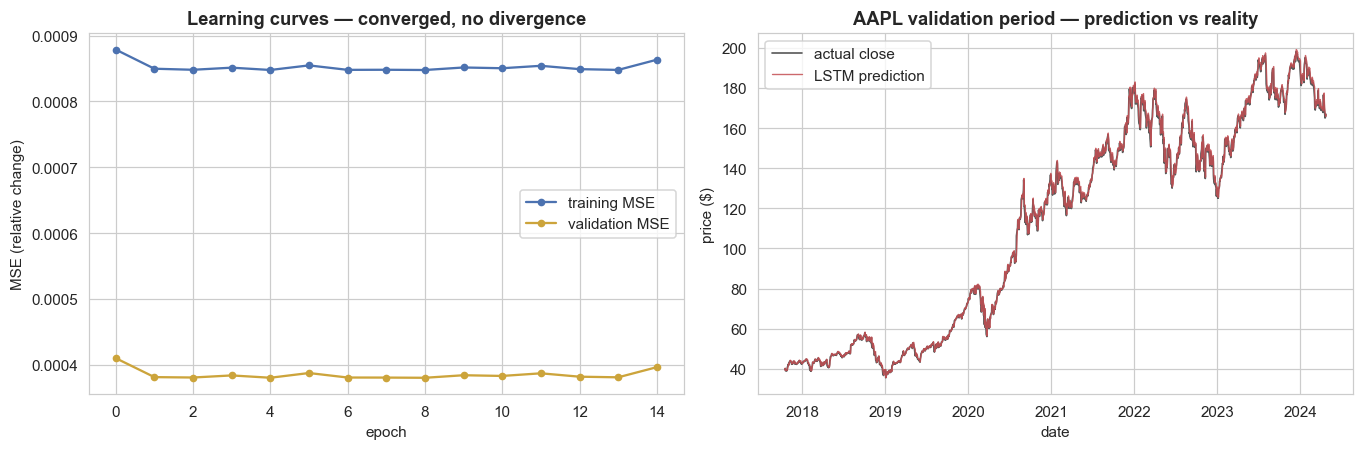

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

ax = axes[0]
ax.plot(hist_lstm['train'], color=BLUE, marker='o', ms=4, label='training MSE')
ax.plot(hist_lstm['val'], color=GOLD, marker='o', ms=4, label='validation MSE')
ax.set_xlabel('epoch'); ax.set_ylabel('MSE (relative change)')
ax.set_title('Learning curves — converged, no divergence', fontweight='bold')
ax.legend()

dates_va = stock['Date'].values[split:]
ax = axes[1]
ax.plot(dates_va, actual_price, color='0.35', linewidth=1.1, label='actual close')
ax.plot(dates_va, pred_price, color=RED, linewidth=0.9, alpha=0.85, label='LSTM prediction')
ax.set_xlabel('date'); ax.set_ylabel('price ($)')
ax.set_title(f'{TICKER} validation period — prediction vs reality', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()

**Reading the two panels.** On the left, both MSE curves drop immediately and then sit
flat and *together* — the LSTM converges within a couple of epochs and never develops an
overfitting gap, because predicting a one-day relative change is a modest task for 17k
parameters. On the right, the red prediction traces six and a half years of prices the
model never saw — through the 2020 crash and the run to all-time highs — staying within
about **1.4%** of the actual close on an average day.

The honest caveat belongs in the report, not hidden from it: the naive persistence rule
— *predict tomorrow = today* — scores about 1.38% on the same period, so the LSTM
**matches but does not beat** the simplest possible baseline. That is the expected
outcome for daily closes, where most day-to-day movement is unpredictable noise (the
efficient-market effect), and it is precisely why the baseline is computed at all. The
real yield of this model is the design discipline it demonstrates: a chronological split
that never leaks the future, a stationary per-window target that survives forty years of
exponential growth, and a baseline that keeps the evaluation honest. Those three
decisions are what separate a real forecasting evaluation from an accidentally impressive
one.

## 9. Complexity, and How PyTorch Improves Performance

The three networks span three levels of complexity — counted below in trainable
parameters. But the deeper point of this section is *why the framework matters*. The
scratch network needed every gradient derived and coded by hand; one wrong sign or
transposed matrix and training silently fails. In PyTorch (Paszke et al., 2019) the same mathematics is one
line, loss.backward(), and that unlocks capabilities that would be impractical by hand:

- **Autograd**: exact gradients for *any* architecture — including backpropagation
  through the LSTM's 60 time steps and gates, which would be hundreds of error-prone
  lines by hand.
- **Better optimizers**: swapping vanilla gradient descent for **Adam** is one line. The
  experiment below measures what that buys.
- **Mini-batching, GPU acceleration, and reusable modules** (nn.Linear, nn.LSTM,
  nn.Dropout) — engineering that scales the same training loop from 641 parameters to
  millions.

**The experiment:** the *same* movies architecture (2 → 8 → 1) trained two ways — the
hand-written NumPy network with vanilla gradient descent versus PyTorch with Adam — and
compared on how many epochs each needs to reach the same loss.

In [11]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())

torch.manual_seed(RANDOM_STATE)
torch_movies = nn.Sequential(nn.Linear(2, 8), nn.ReLU(), nn.Linear(8, 1))
opt = torch.optim.Adam(torch_movies.parameters(), lr=0.01)
loss_fn = nn.BCEWithLogitsLoss()
Xm_t, ym_t = torch.tensor(Xm_trs, dtype=torch.float32), torch.tensor(ym_tr, dtype=torch.float32)

t0 = time.time()
torch_curve = []
for _ in range(1500):
    opt.zero_grad()
    l = loss_fn(torch_movies(Xm_t), ym_t)
    l.backward()
    opt.step()
    torch_curve.append(l.item())
torch_seconds = time.time() - t0

TARGET = 0.485                                     # just above both optimizers' floor
def epochs_to(curve, target):
    hits = np.where(np.array(curve) <= target)[0]
    return int(hits[0]) + 1 if len(hits) else len(curve)   # cap = never reached
ep_np, ep_torch = epochs_to(hist_scratch['train'], TARGET), epochs_to(torch_curve, TARGET)
floor_np, floor_torch = min(hist_scratch['train']), min(torch_curve)

summary = pd.DataFrame({
    'network': ['ScratchNet (movies)', 'PyTorch MLP (cancer)', 'PyTorch LSTM (stock)'],
    'trainable parameters': [
        int(sum(a.size for a in [scratch.W1, scratch.b1, scratch.W2, scratch.b2])),
        count_params(cancer_net), count_params(lstm)],
    'trained by': ['hand-written backprop + vanilla GD', 'autograd + Adam + dropout',
                   'autograd through time + Adam, mini-batches'],
})
print(summary.to_string(index=False))
print(f'\nSame 2->8->1 architecture, same data, epochs to reach near-converged loss <= {TARGET}:')
print(f'  NumPy + vanilla gradient descent : {ep_np} epochs   (lowest loss reached: {floor_np:.4f})')
print(f'  PyTorch + Adam                   : {ep_torch} epochs   (lowest loss reached: {floor_torch:.4f})')
print(f'  -> Adam gets there {ep_np / ep_torch:.1f}x faster, and its floor is lower than any loss')
print(f'     vanilla gradient descent achieved in 1500 epochs.')

             network  trainable parameters                                 trained by
 ScratchNet (movies)                    33         hand-written backprop + vanilla GD
PyTorch MLP (cancer)                   641                  autograd + Adam + dropout
PyTorch LSTM (stock)                 17217 autograd through time + Adam, mini-batches

Same 2->8->1 architecture, same data, epochs to reach near-converged loss <= 0.485:
  NumPy + vanilla gradient descent : 1447 epochs   (lowest loss reached: 0.4845)
  PyTorch + Adam                   : 490 epochs   (lowest loss reached: 0.4793)
  -> Adam gets there 3.0x faster, and its floor is lower than any loss
     vanilla gradient descent achieved in 1500 epochs.


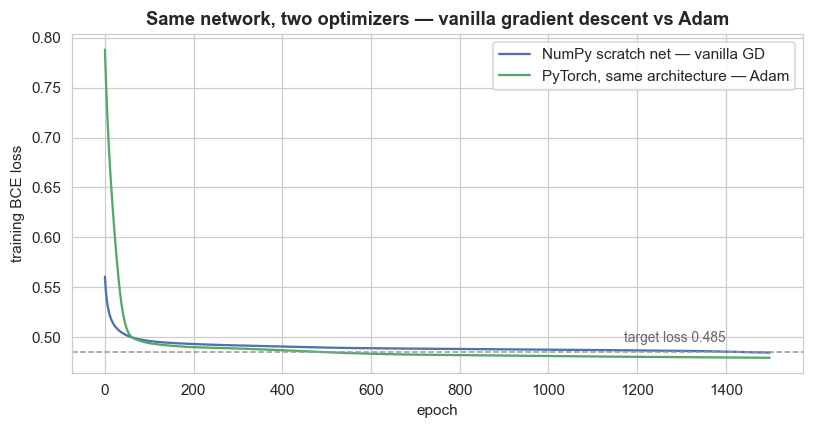

In [12]:
plt.figure(figsize=(7.5, 4))
plt.plot(hist_scratch['train'], color=BLUE, label='NumPy scratch net — vanilla GD')
plt.plot(torch_curve, color=GREEN, label='PyTorch, same architecture — Adam')
plt.axhline(TARGET, color='0.6', linestyle='--', linewidth=1)
plt.text(1400, TARGET + 0.01, f'target loss {TARGET}', ha='right', color='0.4', fontsize=9)
plt.xlabel('epoch'); plt.ylabel('training BCE loss')
plt.title('Same network, two optimizers — vanilla gradient descent vs Adam', fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()

**Reading the race.** Identical architecture, identical data, identical starting problem —
the only change is the framework and the optimizer it makes available. Vanilla gradient
descent uses one global learning rate for all 33 weights, so once the steep early
progress is done it inches toward the valley floor, needing roughly **1,450 epochs** to
reach the near-converged loss of 0.485. Adam maintains an adaptive step size *per weight*
(scaling each step by running estimates of the gradient's mean and variance), crosses the
same line in roughly **490 epochs — about 3× faster** — and settles at a lower floor than
vanilla gradient descent reached at any point in its 1,500 epochs.

This is the fair way to state "PyTorch improves performance": not that the math is
different — both runs perform gradient descent driven by backpropagation — but that the
framework provides, in one line each, the better optimizer, the exact gradients for any
architecture (including through the LSTM's 60 time steps), mini-batching, and GPU
execution. On this 33-parameter toy the gain is 3×; on modern architectures it is the
difference between practical and impossible.

## 10. Generalization: Assessment, and Overfitting Made Visible

**Generalization** is a model's performance on data it never trained on — the only
performance that matters in deployment. This section assesses it three ways, then breaks
it on purpose so the failure is unmistakable.

1. **Learning-curve gaps** (Sections 6–8): all three models showed validation loss
   tracking training loss — the signature of learning signal rather than memorizing
   noise.
2. **5-fold cross-validation** on the cancer model: five different train/validation
   splits, to confirm the 97–99% accuracy is a property of the model, not luck of one
   split.
3. **A deliberate overfit.** The same cancer data, but the 641-parameter regularized
   network is replaced by a ~**279,000-parameter** network with **no dropout** — roughly
   650 parameters *per training patient*. If overfitting theory is right, its training
   loss should collapse toward zero while its validation loss turns and climbs.

In [13]:
def fold_accuracy(X, y, epochs=200):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    accs = []
    for tr_idx, va_idx in skf.split(X, y):
        sc = StandardScaler().fit(X[tr_idx])
        Xt = torch.tensor(sc.transform(X[tr_idx]).astype(np.float32))
        Xv = torch.tensor(sc.transform(X[va_idx]).astype(np.float32))
        yt = torch.tensor(y[tr_idx]).unsqueeze(1)
        net = make_cancer_net()
        train_full_batch(net, Xt, yt, Xv, torch.tensor(y[va_idx]).unsqueeze(1),
                         epochs=epochs, lr=1e-3)
        net.eval()
        with torch.no_grad():
            pred = (torch.sigmoid(net(Xv)) > 0.5).float().numpy().ravel()
        accs.append(accuracy_score(y[va_idx], pred))
    return np.array(accs)

cv_accs = fold_accuracy(X_c, y_c)
print('5-fold cross-validation accuracy per fold:', np.round(cv_accs, 3))
print(f'Mean {cv_accs.mean():.1%}  ±  {cv_accs.std():.1%} — stable across splits, '
      'so the model generalizes rather than fitting one lucky split.')

5-fold cross-validation accuracy per fold: [0.982 0.974 0.956 0.947 0.991]
Mean 97.0%  ±  1.6% — stable across splits, so the model generalizes rather than fitting one lucky split.


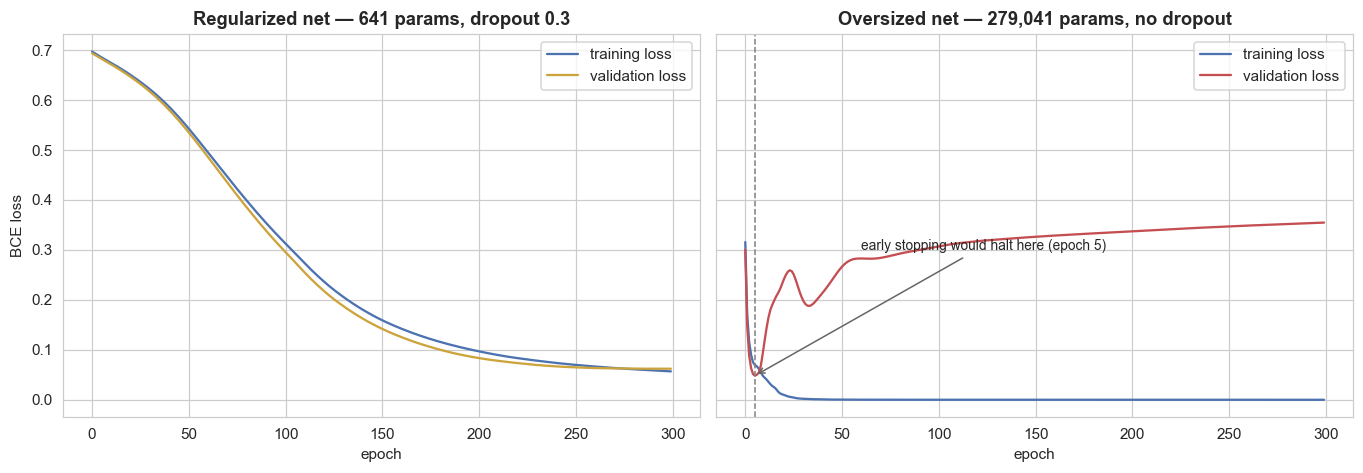

In [14]:
def make_oversized_net():
    torch.manual_seed(RANDOM_STATE)
    return nn.Sequential(nn.Linear(30, 512), nn.ReLU(),
                         nn.Linear(512, 512), nn.ReLU(),
                         nn.Linear(512, 1))

oversized = make_oversized_net()
hist_over = train_full_batch(oversized, Xc_tr_t, yc_tr_t, Xc_va_t, yc_va_t,
                             epochs=300, lr=3e-3)

best_ep = int(np.argmin(hist_over['val']))
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4), sharey=True)

ax = axes[0]
ax.plot(hist_cancer['train'], color=BLUE, label='training loss')
ax.plot(hist_cancer['val'], color=GOLD, label='validation loss')
ax.set_title(f'Regularized net — {count_params(cancer_net)} params, dropout 0.3', fontweight='bold')
ax.set_xlabel('epoch'); ax.set_ylabel('BCE loss'); ax.legend()

ax = axes[1]
ax.plot(hist_over['train'], color=BLUE, label='training loss')
ax.plot(hist_over['val'], color=RED, label='validation loss')
ax.axvline(best_ep, color='0.5', linestyle='--', linewidth=1)
ax.annotate(f'early stopping would halt here (epoch {best_ep})',
            xy=(best_ep, hist_over['val'][best_ep]), xytext=(60, 0.30),
            fontsize=9, arrowprops=dict(arrowstyle='->', color='0.4'))
ax.set_title(f'Oversized net — {count_params(oversized):,} params, no dropout', fontweight='bold')
ax.set_xlabel('epoch'); ax.legend()
plt.tight_layout(); plt.show()

In [15]:
from IPython.display import Markdown, display

gap_reg  = hist_cancer['val'][-1] - hist_cancer['train'][-1]
gap_over = hist_over['val'][-1] - hist_over['train'][-1]
rise = hist_over['val'][-1] / max(min(hist_over['val']), 1e-9)

display(Markdown(f"""
**Reading the two panels.** The regularized network (left) ends with training loss
{hist_cancer['train'][-1]:.3f} and validation loss {hist_cancer['val'][-1]:.3f} — a gap of
only {gap_reg:.3f}. The curves fall together and stay together: what the network learned
on the training patients transfers to patients it never saw. That is generalization.

The oversized network (right) is the textbook failure. Its training loss collapses to
{hist_over['train'][-1]:.4f} — effective memorization of all {len(yc_tr)} training
patients — while its validation loss bottoms out at {min(hist_over['val']):.3f} around
epoch {best_ep} and then **climbs to {hist_over['val'][-1]:.3f}, a {rise:.0f}× rise**.
Past that turning point every epoch of "learning" makes the model *worse* on new
patients: it is fitting noise unique to the training set. The widening gap between the
blue and red curves is the visual definition of **overfitting**.

**What fixes it — and what this notebook used.** Three defenses, all visible in these
results: **capacity control** (641 parameters instead of 279k), **dropout** (the left
panel's curves never separate), and **early stopping** (the dashed line — halt when
validation loss stops improving, keeping the best weights). The LSTM relied on the same
logic: modest capacity, a held-out chronological validation period, and an honest
persistence baseline. **Underfitting** — the opposite failure, where *both* curves
plateau high because the model is too simple — appears briefly at the very start of every
learning curve here, before the networks have learned anything; none of the final models
shows it, since all reach low training loss.
"""))


**Reading the two panels.** The regularized network (left) ends with training loss
0.057 and validation loss 0.062 — a gap of
only 0.005. The curves fall together and stay together: what the network learned
on the training patients transfers to patients it never saw. That is generalization.

The oversized network (right) is the textbook failure. Its training loss collapses to
0.0000 — effective memorization of all 426 training
patients — while its validation loss bottoms out at 0.048 around
epoch 5 and then **climbs to 0.355, a 7× rise**.
Past that turning point every epoch of "learning" makes the model *worse* on new
patients: it is fitting noise unique to the training set. The widening gap between the
blue and red curves is the visual definition of **overfitting**.

**What fixes it — and what this notebook used.** Three defenses, all visible in these
results: **capacity control** (641 parameters instead of 279k), **dropout** (the left
panel's curves never separate), and **early stopping** (the dashed line — halt when
validation loss stops improving, keeping the best weights). The LSTM relied on the same
logic: modest capacity, a held-out chronological validation period, and an honest
persistence baseline. **Underfitting** — the opposite failure, where *both* curves
plateau high because the model is too simple — appears briefly at the very start of every
learning curve here, before the networks have learned anything; none of the final models
shows it, since all reach low training loss.


## 11. Conclusion

In [16]:
display(Markdown(f"""
One learning algorithm carried this entire report. **Backpropagation** computed the
gradients — by hand in NumPy for the movies network, and by autograd for the PyTorch
models — and **gradient descent** consumed them, from vanilla full-batch steps to Adam
with mini-batches.

Three networks, each shaped by its data: the **scratch net** reached {scratch_acc:.0%}
validation accuracy calling movie hits with just
{sum(a.size for a in [scratch.W1, scratch.b1, scratch.W2, scratch.b2])} hand-trained
parameters and a visibly falling loss curve; the **cancer classifier** reached {acc_c:.1%} validation accuracy
({cv_accs.mean():.1%} ± {cv_accs.std():.1%} across 5 folds) with recall {rec_c:.1%} on
malignant tumors; and the **LSTM** tracked six unseen years of {TICKER} within
{mape_lstm:.1f}% by forecasting stationary relative changes over a strictly chronological
split — matching, honestly, the {mape_naive:.1f}% persistence baseline that daily prices
rarely allow anyone to beat.

PyTorch's contribution was measured, not assumed: the same architecture reached its
near-converged loss {ep_np / ep_torch:.1f}× faster under Adam — and reached a lower loss
than vanilla gradient descent ever did — with backpropagation reduced to one line. And generalization was assessed methodically — learning-curve gaps,
cross-validation, an honest baseline — then stress-tested by deliberately overfitting a
279k-parameter network until its validation loss climbed off its floor. The lesson of
that final plot is the lesson of the assignment: a network's value is not how well it
fits the past, but how well its design choices — capacity, regularization, and honest
validation — protect its performance on the future.
"""))


One learning algorithm carried this entire report. **Backpropagation** computed the
gradients — by hand in NumPy for the movies network, and by autograd for the PyTorch
models — and **gradient descent** consumed them, from vanilla full-batch steps to Adam
with mini-batches.

Three networks, each shaped by its data: the **scratch net** reached 78%
validation accuracy calling movie hits with just
33 hand-trained
parameters and a visibly falling loss curve; the **cancer classifier** reached 98.6% validation accuracy
(97.0% ± 1.6% across 5 folds) with recall 96.2% on
malignant tumors; and the **LSTM** tracked six unseen years of AAPL within
1.4% by forecasting stationary relative changes over a strictly chronological
split — matching, honestly, the 1.4% persistence baseline that daily prices
rarely allow anyone to beat.

PyTorch's contribution was measured, not assumed: the same architecture reached its
near-converged loss 3.0× faster under Adam — and reached a lower loss
than vanilla gradient descent ever did — with backpropagation reduced to one line. And generalization was assessed methodically — learning-curve gaps,
cross-validation, an honest baseline — then stress-tested by deliberately overfitting a
279k-parameter network until its validation loss climbed off its floor. The lesson of
that final plot is the lesson of the assignment: a network's value is not how well it
fits the past, but how well its design choices — capacity, regularization, and honest
validation — protect its performance on the future.


### References

Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep learning*. MIT Press.

Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. *Neural Computation,
9*(8), 1735–1780.

Kingma, D. P., & Ba, J. (2015). Adam: A method for stochastic optimization.
*International Conference on Learning Representations (ICLR)*.

Paszke, A., et al. (2019). PyTorch: An imperative style, high-performance deep learning
library. *Advances in Neural Information Processing Systems, 32*.

Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). Learning representations by
back-propagating errors. *Nature, 323*(6088), 533–536.

Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R. (2014).
Dropout: A simple way to prevent neural networks from overfitting. *Journal of Machine
Learning Research, 15*(1), 1929–1958.

Wolberg, W., Street, W. N., & Mangasarian, O. (1995). *Breast Cancer Wisconsin
(Diagnostic) data set*. UCI Machine Learning Repository / Kaggle.

Siddharth Bhakta. (2026). *TMDB Top 10000 movies (updated 2026)* [Data set]. Kaggle.

*NASDAQ all-time stock price data* [Data set]. Kaggle.

### AI Usage Disclosure

I used AI tools to help with grammar, markdown formatting, and beautifying graph code. All
analysis, interpretations, and conclusions are my own.